In [153]:
import numpy as np
import PyWSINDy_ODE.wsindy as ws
import PyWSINDy_ODE.ODE_examples as ODE_examples 
import matplotlib.pylab as plt
from scipy.integrate import solve_ivp
from mpl_toolkits import mplot3d

from agl_helpers import addNoise, recoverDynamics

def addNoise(x, noise_ratio):
    signal_power = np.sqrt(np.mean(x**2))
    sigma = noise_ratio*signal_power
    noise = np.random.normal(0, sigma, x.shape)
    xobs = x + noise
    return xobs

True The solver successfully reached the end of the integration interval. 29.990000000000002 (3000, 3)


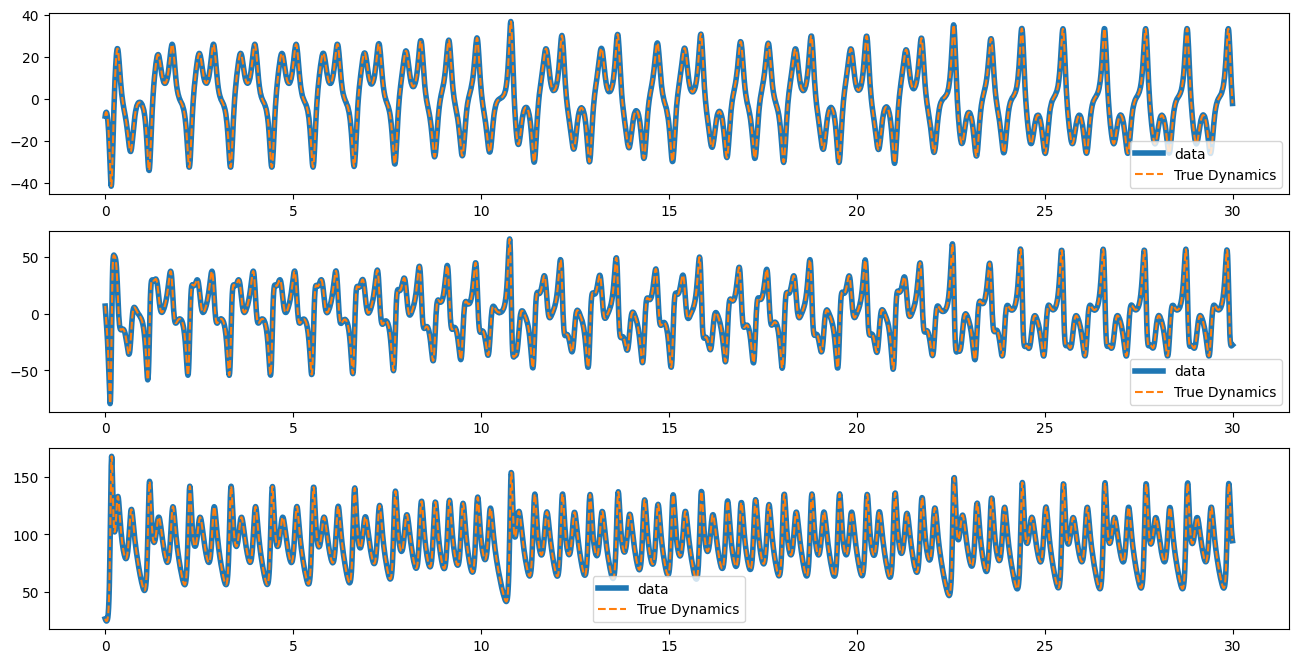

In [154]:
t_span = np.array([0,30])
t_eval = np.arange(0,30,0.01)
noise_ratio = 0.001



sigma = 10
rho = 100
beta = 8/3

def rhs(t, s): #original Lorenz
            # z = [x, y, eta, mx, cx, my, cy]
            x, y, z = s



            dx = sigma*(y-x)
            dy = x*(rho-z) - y 
            dz = x*y-beta*z



            return np.array([dx, dy, dz])

x0 = np.array([-8 ,7 ,27]).T


sol = solve_ivp(fun=rhs, t_eval=t_eval, t_span=t_span, y0=x0, rtol=1e-6)
print(sol.success, sol.message, sol.t[-1], sol.y.T.shape)


x = sol.y.T
t = sol.t
xobs = addNoise(x=sol.y.T,noise_ratio=noise_ratio)

# plt.plot(sol.t,xobs)
fig = plt.figure(figsize=(16, 8))
c = 1
n = xobs.shape[1]
for d in range(n):
    plt.subplot(n, 1, c)
    plt.plot(t, xobs[:, d], label = "data", linewidth = 4)
    plt.plot(t, x[:, d], "--", label = 'True Dynamics',)
    c = c + 1
    plt.legend()

In [155]:
WSINDy_model = ws.wsindy(polys=np.arange(0, 3),ld=0.05
                         )

#Uniform
# WSINDy_model.getWSindyUniform(xobs, t, L = 30, overlap=0.7)

#Uniform shortened time
print(xobs.shape[0])
training_time = 10
t_training = t[0:training_time*10**2]
xobs_training = xobs[0:training_time*10**2,:]
WSINDy_model.getWSindyUniform(xobs_training, t_training, L = 15, overlap=0.7)



t_ws, WSINDy_sim = WSINDy_model.simulate(t_span = [t[0],t[-1]], t_eval = t, x0 = xobs[0,:])

recoverDynamics(WSINDy_model)

3000
True The solver successfully reached the end of the integration interval. 29.990000000000002 (3000, 3)
dx0/dt = -0.0006 + (9.9953)x1 + (-9.9983)x0
dx1/dt = -0.0586 + (-0.9984)x1 + (100.0278)x0 + (-1.0002)x0x2
dx2/dt = 0.0314 + (-2.6673)x2 + (1.0004)x0x1


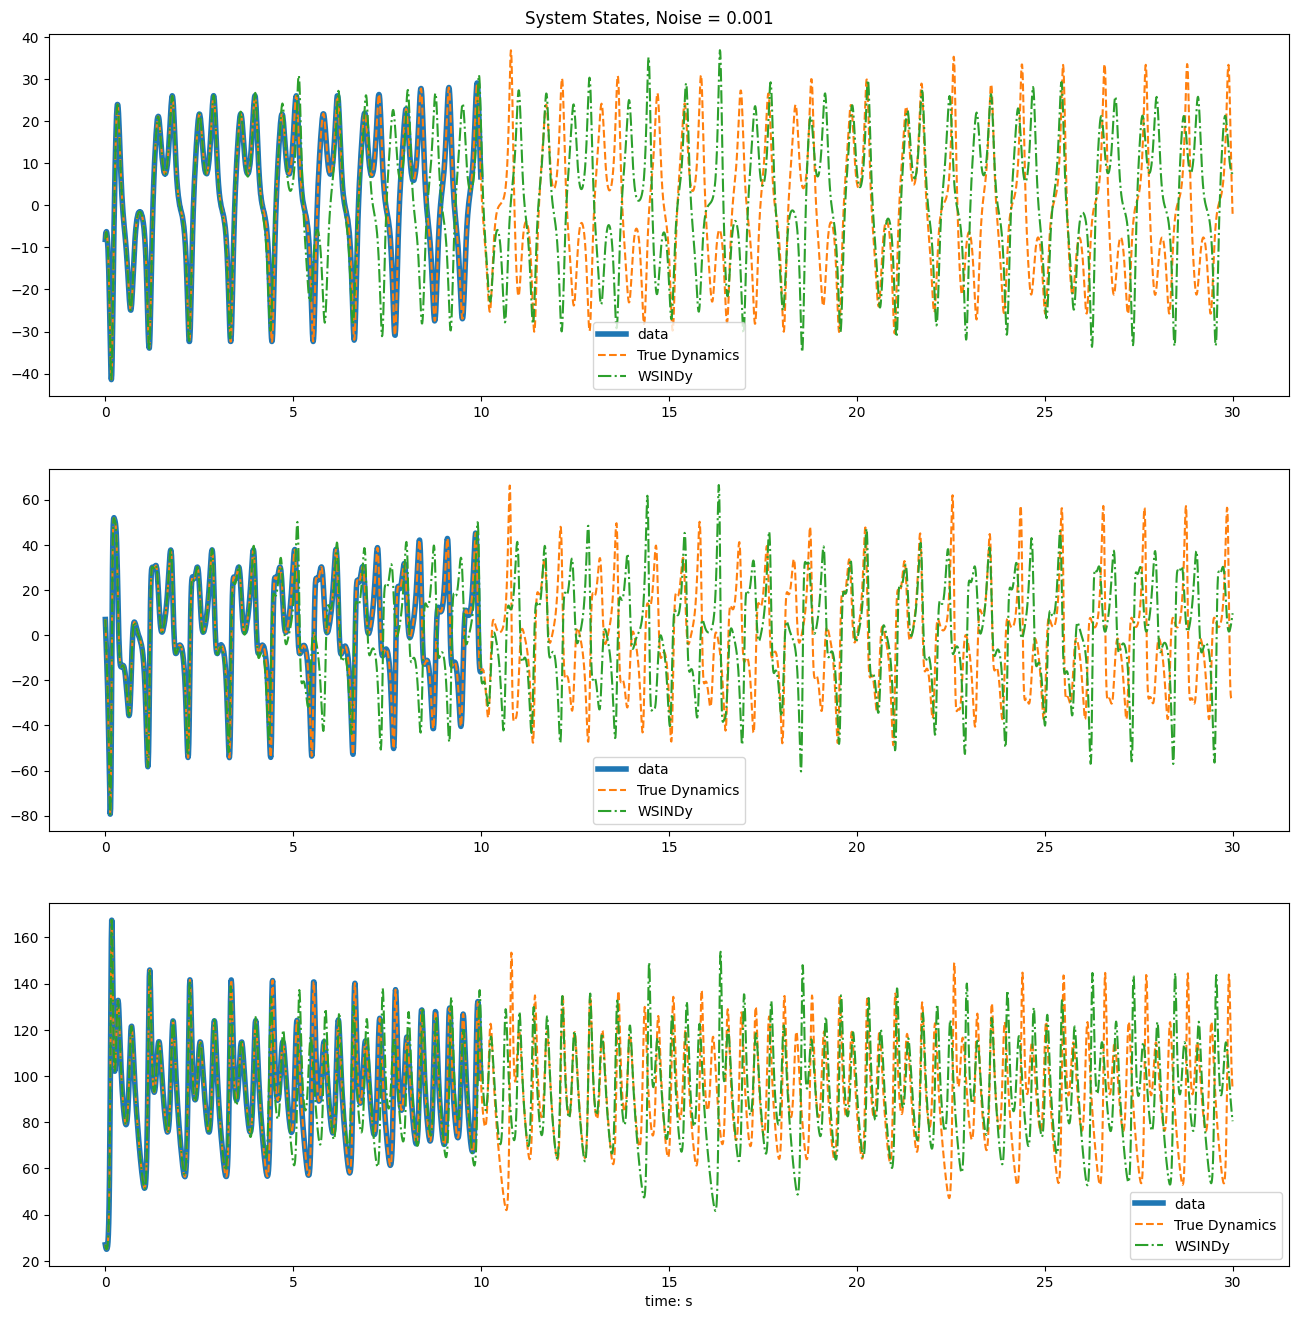

In [156]:
fig = plt.figure(figsize=(16, 16))
c = 1
n = xobs.shape[1]
plt.suptitle(f"System States, Noise = {noise_ratio}",y=0.895)

# plt.xlabel('time: s')
for d in range(n):
    plt.subplot(n, 1, c)
    plt.plot(t_training, xobs_training[:, d], label = "data", linewidth = 4)
    plt.plot(t, x[:, d], linestyle = "--", label = 'True Dynamics',) #marker = 'o', markevery=300)
    plt.plot(t_ws, WSINDy_sim[:, d], linestyle='dashdot', label = 'WSINDy') #marker = 'v', markevery = 200)
    # plt.subplots_adjust(hspace=0.4)
    if d == n - 1:
        plt.xlabel('time: s')
    
    c = c + 1
    plt.legend()
    

# plt.show()

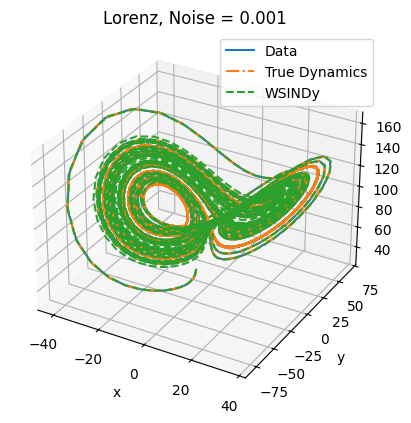

In [157]:
fig = plt.figure()
ax = plt.axes(projection = '3d')
ax.set_zlabel('z',labelpad=20)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.plot3D(xobs[:,0],xobs[:,1],xobs[:,2])
ax.plot3D(x[:,0],x[:,1],x[:,2],linestyle = 'dashdot')
ax.plot3D(WSINDy_sim[:,0],WSINDy_sim[:,1],WSINDy_sim[:,2],'--')
plt.legend(['Data','True Dynamics','WSINDy'])
plt.title(f"Lorenz, Noise = {noise_ratio}")
plt.show()

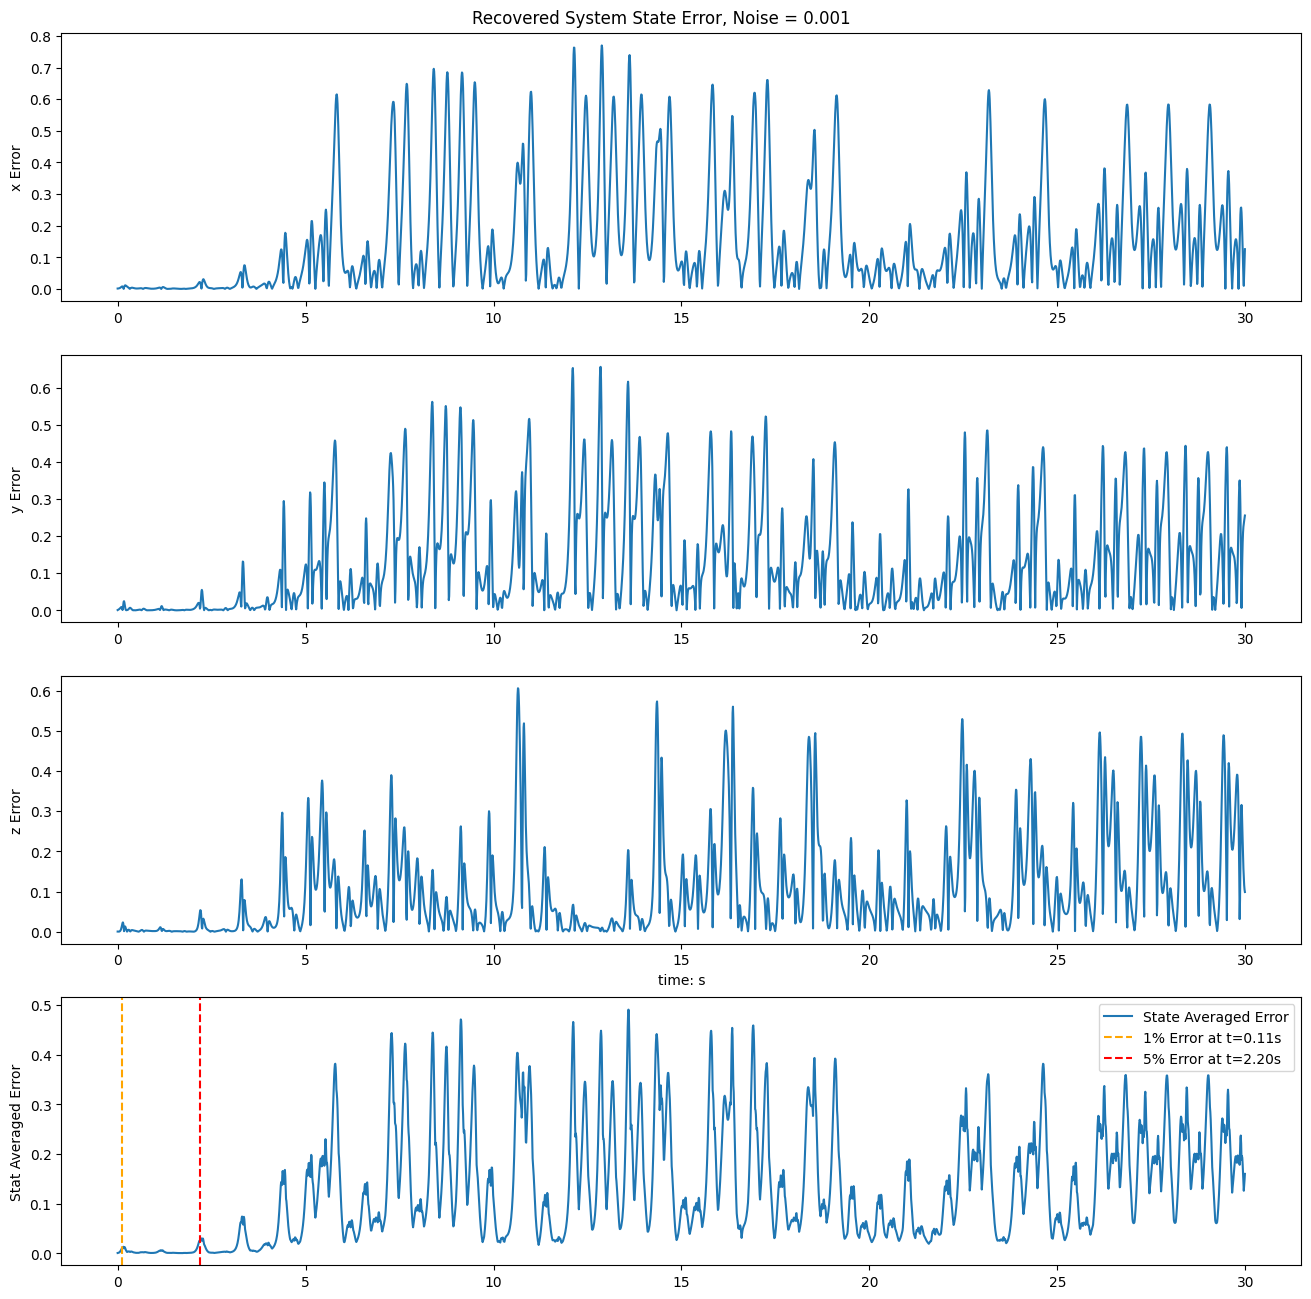

In [158]:
# x_error = x[:,0] - WSINDy_sim[:,0]
# plt.plot(x_error)

fig = plt.figure(figsize=(16, 16))
c = 1
n = 3
plt.suptitle(f"Recovered System State Error, Noise = {noise_ratio}",y=0.895)

states = ['x Error','y Error','z Error']
state_range = np.ptp(x, axis=0)
error = np.abs(x - WSINDy_sim) / state_range
error_threshold = 0.01
error_crossings_01 = np.where(error >= 0.01)[0]
error_crossings_05 = np.where(error >= 0.05)[0]
for d in range(n):
    plt.subplot(4, 1, c)
    

    plt.plot(t, error[:,d], label = str(states[d])+" Error")
    plt.ylabel(states[d])
    if d == n - 1:
        plt.xlabel('time: s')
    
    c = c + 1
    # plt.legend()
plt.subplot(4, 1, 4)
# state_avg_error = abs(1/3 * (x[:,0]-WSINDy_sim[:,0])) + abs(1/3 * (x[:,1]-WSINDy_sim[:,1])) + abs(1/3 * (x[:,2]-WSINDy_sim[:,2]))
state_avg_error = np.mean(error,axis=1)
error_crossings_01 = np.where(error >= 0.01)[0]
error_crossings_05 = np.where(error >= 0.05)[0]
plt.plot(t,state_avg_error,label = 'State Averaged Error')
crossing_time_01 = t[error_crossings_01[0]]
crossing_time_05 = t[error_crossings_05[0]]
plt.axvline(crossing_time_01, color = 'orange', linestyle='--', label=f'1% Error at t={crossing_time_01:.2f}s')
plt.axvline(crossing_time_05, color = 'red', linestyle='--', label=f'5% Error at t={crossing_time_05:.2f}s')

plt.ylabel('Stat Averaged Error')
plt.legend()

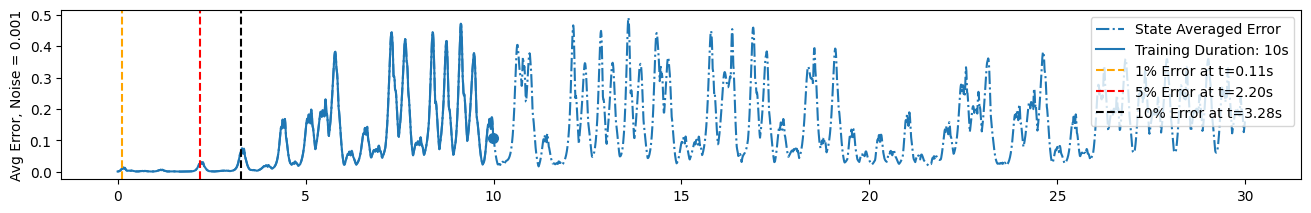

In [159]:
error = np.abs(x - WSINDy_sim) / state_range
fig = plt.figure(figsize=(16, 2.2))
state_range = np.ptp(x, axis=0)
state_avg_error = np.mean(error,axis=1)
error_crossings_01 = np.where(error >= 0.01)[0]
error_crossings_05 = np.where(error >= 0.05)[0]
error_crossings_10 = np.where(error >= 0.1)[0]
plt.plot(t,state_avg_error,label = 'State Averaged Error',linestyle = 'dashdot')
plt.plot(t_training,state_avg_error[0:training_time*10**2],label = f'Training Duration: {training_time}s',color = 'C0')
plt.plot(t_training[-1],state_avg_error[training_time*10**2],'o',markersize = 7, color = "C0")
crossing_time_01 = t[error_crossings_01[0]]
crossing_time_05 = t[error_crossings_05[0]]
crossing_time_10 = t[error_crossings_10[0]]
plt.axvline(crossing_time_01, color = 'orange', linestyle='--', label=f'1% Error at t={crossing_time_01:.2f}s')
plt.axvline(crossing_time_05, color = 'red', linestyle='--', label=f'5% Error at t={crossing_time_05:.2f}s')
plt.axvline(crossing_time_10, color = 'black', linestyle='--', label=f'10% Error at t={crossing_time_10:.2f}s')
plt.ylabel(f'Avg Error, Noise = {noise_ratio}')
plt.legend(loc = "upper right")
# plt.title(f"State Averaged Error, Noise = {noise_ratio}")